# Amazon Product Reviews — Multi-Class Sentiment Analysis and Topic Modelling

**Student:** Revathi Sivasankaran | **ID:** 4371ORRN | **Module:** 7FTC2007

---

## Phase 0 — Setup and Configuration

Import all required libraries and define global configuration variables such as file paths, sample sizes, and memory helpers. All settings are centralised here so the rest of the notebook can run without modification.

In [1]:
#Importing Librabries
import os, csv, gc, time, psutil, warnings, random, hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

project_path = '/content/drive/MyDrive/amazon_project'
os.makedirs(project_path, exist_ok=True)

PARQUET_PATH = f'{project_path}/reviews_clean_sample.parquet'
FLAGGED_PATH = f'{project_path}/reviews_flagged_sample.csv'
CSV_PATH     = f'{project_path}/amazon_reviews.csv'

# Colab Limits
SAMPLE_SIZE      = 50_000   # Main working sample for plotting/EDA (from processed data)
MAX_DOWNLOAD_ROWS= 200_000  # Number of rows to randomly sample from raw TSV into CSV
CL_SIZE          = 80_000   # Classical-model training cap
BERT_TRAIN       = 10_000   # DistilBERT training cap
BERT_EVAL        = 2_000    # DistilBERT eval cap
LDA_SIZE         = 20_000   # LDA topic-modelling cap
BERTOPIC_SIZE    = 10_000   # BERTopic cap

def ram():
    return os.getloadavg()[0] if hasattr(os, 'getloadavg') else psutil.virtual_memory().percent

def ram_guard(label='', threshold=85):
    """Warn loudly if RAM exceeds threshold."""
    pct = psutil.virtual_memory().percent
    if pct > threshold:
        print(f"  RAM CRITICAL at {label}: {pct}% — running gc.collect()")
        gc.collect()
    return pct

print(f" Setup complete | Max processed rows: {MAX_DOWNLOAD_ROWS:,} | RAM: {psutil.virtual_memory().percent}%")


 Setup complete | Max processed rows: 200,000 | RAM: 8.5%


## Phase 1 — Data Acquisition

### Step 1.1 — Download Dataset from Kaggle

Download the Amazon US Customer Reviews Dataset from Kaggle using the `kagglehub` library. The raw file is in TSV (tab-separated values) format. If a cached CSV already exists from a previous run, this step is skipped automatically.

In [2]:
# Data Download
tsv_path = None
data_source = 'unknown'

if not os.path.exists(CSV_PATH):
    try:
        !pip install kagglehub==0.3.6 -q
        import kagglehub
        print("Downloading single file from Kaggle (timeout 120s)...")
        tsv_path = kagglehub.dataset_download(
            "cynthiarempel/amazon-us-customer-reviews-dataset",
            path="amazon_reviews_multilingual_US_v1_00.tsv"
        )
        data_source = 'kaggle'
        print(f" Downloaded → {tsv_path} | RAM: {ram()}%")
    except Exception as e:
        print(f"  Download failed: {e}")
        raise FileNotFoundError(" Kaggle dataset download failed. Please place your CSV file at CSV_PATH manually.")
elif os.path.exists(CSV_PATH):
    data_source = 'cached_csv'
    print(f" Using cached CSV: {CSV_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.9 MB/s eta 0:00:00


100%|██████████| 1.38G/1.38G [00:15<00:00, 93.3MB/s]

Extracting zip of amazon_reviews_multilingual_US_v1_00.tsv...


 Downloaded → /root/.cache/kagglehub/datasets/cynthiarempel/amazon-us-customer-reviews-dataset/versions/9/amazon_reviews_multilingual_US_v1_00.tsv | RAM: 3.7890625%


### Step 1.2 — TSV to CSV Conversion with Reservoir Sampling

Convert the raw TSV file to CSV and simultaneously draw a random sample of 200,000 rows using **reservoir sampling** with `random.seed(42)`. This guarantees every row in the 6.9 million record dataset has an equal probability of being selected — not just the first 200,000 rows. The fixed seed ensures the same rows are chosen every run, making results fully reproducible.

In [3]:
import random

if data_source == 'kaggle' and tsv_path is not None:
    csv.field_size_limit(10 * 1024 * 1024)
    print(f"Converting TSV to CSV (randomly sampling {MAX_DOWNLOAD_ROWS:,} rows from full dataset)...")

    random.seed(42)  # ADD THIS LINE — makes sampling reproducible every run

    reservoir = []
    header = None
    total_lines_read = 0

    with open(tsv_path, 'r', encoding='utf-8') as tsv_f:
        tsv_reader = csv.reader(tsv_f, delimiter='\t')
        header = next(tsv_reader)

        for i, row in enumerate(tsv_reader):
            total_lines_read += 1
            if len(reservoir) < MAX_DOWNLOAD_ROWS:
                reservoir.append(row)
            else:
                j = random.randrange(total_lines_read)
                if j < MAX_DOWNLOAD_ROWS:
                    reservoir[j] = row

            if total_lines_read % 100_000 == 0:
                print(f"   Processed {total_lines_read:,} lines | RAM: {ram()}%")

    print(f"Finished reading TSV. Total lines: {total_lines_read:,}. Sampled {len(reservoir):,} rows.")

    with open(CSV_PATH, 'w', newline='', encoding='utf-8') as csv_f:
        csv_writer = csv.writer(csv_f)
        if header:
            csv_writer.writerow(header)
        csv_writer.writerows(reservoir)

    data_source = 'cached_csv'
    print(f"Done. Saved to {CSV_PATH} | RAM: {ram()}%")

elif data_source == 'cached_csv':
    print("Skipping conversion (using cached CSV)")
else:
    raise FileNotFoundError("No valid data source found.")

Converting TSV to CSV (randomly sampling 200,000 rows from full dataset)...
   Processed 100,000 lines | RAM: 3.7890625%
   Processed 200,000 lines | RAM: 3.7890625%
   Processed 300,000 lines | RAM: 3.7890625%
   Processed 400,000 lines | RAM: 3.5654296875%
   Processed 500,000 lines | RAM: 3.5654296875%
   Processed 600,000 lines | RAM: 3.5654296875%
   Processed 700,000 lines | RAM: 3.5654296875%
   Processed 800,000 lines | RAM: 3.35986328125%
   Processed 900,000 lines | RAM: 3.35986328125%
   Processed 1,000,000 lines | RAM: 3.35986328125%
   Processed 1,100,000 lines | RAM: 3.17041015625%
   Processed 1,200,000 lines | RAM: 3.17041015625%
   Processed 1,300,000 lines | RAM: 3.17041015625%
   Processed 1,400,000 lines | RAM: 3.17041015625%
   Processed 1,500,000 lines | RAM: 3.17041015625%
   Processed 1,600,000 lines | RAM: 2.99658203125%
   Processed 1,700,000 lines | RAM: 2.99658203125%
   Processed 1,800,000 lines | RAM: 2.99658203125%
   Processed 1,900,000 lines | RAM: 2.99

### Step 1.3 — Verify and Load CSV

Confirm the CSV file exists at the expected path before continuing. This prevents silent failures later in the pipeline if the download or conversion step failed.

In [4]:
#Load & Sample Review
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f" Amazon reviews dataset CSV file not found at {CSV_PATH}. Please place it there to continue.")
print(f" CSV file verified: {CSV_PATH}. Starting pipeline...")
data_source = 'cached_csv'

 CSV file verified: /content/drive/MyDrive/amazon_project/amazon_reviews.csv. Starting pipeline...


## Phase 2 — Fake Review Detection

### Step 2.1 — Pass 1: Count Burst Reviewers (Signals 1–6)

Scan the full CSV to count how many reviews each customer posted on each date. This detects **burst posting** — customers who posted 5 or more reviews on the same day, which is a strong indicator of coordinated fake review activity. This pass reads only two columns (`customer_id`, `review_date`) to keep memory usage minimal.

In [5]:
# Suspicious signal 1-6
from collections import Counter
print("Pass 1: Counting reviewer burst dates globally...")
burst_counter = Counter()
total_rows = 0

for chunk in pd.read_csv(CSV_PATH, usecols=['customer_id', 'review_date'], chunksize=50000, on_bad_lines='skip', dtype=str):
    chunk = chunk.dropna()
    pairs = zip(chunk['customer_id'], chunk['review_date'].str.strip())
    burst_counter.update(pairs)
    total_rows += len(chunk)

print(f"✅ Pass 1 done. Counted {len(burst_counter):,} unique user-date pairs across {total_rows:,} rows. RAM: {ram()}%")

Pass 1: Counting reviewer burst dates globally...
✅ Pass 1 done. Counted 198,489 unique user-date pairs across 199,996 rows. RAM: 2.23388671875%


### Step 2.2 — Pass 2: Apply All 7 Signals and Split Clean / Flagged

Process the full CSV in chunks of 50,000 rows. For each review, compute all seven suspicion signals and sum them into a weighted composite score. Reviews scoring 2.0 or above are written to the flagged CSV. The remaining clean reviews are written to a staging CSV for sampling. Signal 7 uses VADER sentiment analysis to detect mismatch between review text polarity and the star rating given.

In [6]:
#Suspicious Signal 7
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print(f"Pass 2: Computing all 7 signals and splitting clean/flagged in chunks...")
# Pre-compile flat keys dictionary for vectorized burst lookup
burst_dict = {f"{cust}_{dt}": cnt for (cust, dt), cnt in burst_counter.items()}
analyzer = SentimentIntensityAnalyzer()
WEIGHTS = {
    'flag_vine':0.5, 'flag_unverified':0.5, 'flag_too_short':1.0,
    'flag_generic':1.5, 'flag_unhelpful':1.5, 'flag_burst':2.0, 'flag_mismatch':1.5
}
THRESHOLD = 2.0
flag_cols = list(WEIGHTS.keys())
BOT_PHRASES = (
    'five stars|perfect product|excellent product|as described|'
    'highly recommend this product|exactly as advertised|'
    'great seller|fast shipping great product|'
    'received this product for free|received this product in exchange|'
    'i received this product|disclaimer|complimentary|'
    'honest and unbiased|in exchange for my honest'
)
MISMATCH_T = {1.0:1.2, 2.0:0.9, 3.0:0.7, 4.0:0.9, 5.0:1.2}

# Output files setup
STAGING_PATH = PARQUET_PATH.replace('.parquet', '_staging.csv')
if os.path.exists(FLAGGED_PATH):  os.remove(FLAGGED_PATH)
if os.path.exists(PARQUET_PATH):  os.remove(PARQUET_PATH)
if os.path.exists(STAGING_PATH):  os.remove(STAGING_PATH)

total_clean   = 0
total_flagged = 0
chunk_idx     = 0
first_flagged = True
first_clean   = True

mismatch_counts = {s: 0 for s in MISMATCH_T}
mismatch_flags = {s: 0 for s in MISMATCH_T}

for chunk in pd.read_csv(CSV_PATH, chunksize=50000, on_bad_lines='skip', dtype=str):
    chunk_idx += 1
    # Data type cleaning
    chunk['star_rating']   = pd.to_numeric(chunk['star_rating'],   errors='coerce')
    chunk['helpful_votes'] = pd.to_numeric(chunk['helpful_votes'], errors='coerce').fillna(0).astype(np.int32)
    chunk['total_votes']   = pd.to_numeric(chunk['total_votes'],   errors='coerce').fillna(0).astype(np.int32)
    chunk['review_body']   = chunk['review_body'].fillna('')
    chunk['review_length'] = chunk['review_body'].str.len().astype(np.int32)

    # Signal 1: Vine
    chunk['flag_vine'] = chunk['vine'].astype(str).str.strip().str.upper() == 'Y'
    # Signal 2: Unverified
    chunk['flag_unverified'] = chunk['verified_purchase'].astype(str).str.strip().str.upper() == 'N'
    # Signal 3: Short review
    chunk['flag_too_short'] = chunk['review_length'] < 15
    # Signal 4: Generic/Bot
    chunk['flag_generic'] = (
        chunk['review_body'].str.lower().str.contains(BOT_PHRASES, na=False, regex=True) &
        (chunk['review_length'] < 60)
    )
    # Signal 5: Unhelpful ratio
    has_votes = chunk['total_votes'] >= 5
    chunk['helpful_ratio'] = np.where(has_votes, chunk['helpful_votes']/chunk['total_votes'], np.nan).astype(np.float32)
    chunk['flag_unhelpful'] = (chunk['helpful_ratio'] < 0.3).fillna(False)
    # Signal 6: Burst (vectorized mapping)
    keys = chunk['customer_id'].astype(str) + "_" + chunk['review_date'].astype(str).str.strip()
    chunk['flag_burst'] = keys.map(burst_dict).fillna(0) >= 5
    # Signal 7: VADER Mismatch
    chunk['star_normalised'] = ((chunk['star_rating'] - 3) / 2).astype(np.float32)
    chunk['text_polarity'] = chunk['review_body'].apply(
        lambda x: analyzer.polarity_scores(str(x))['compound']
    ).astype(np.float32)
    chunk['_mt'] = chunk['star_rating'].map(MISMATCH_T).fillna(0.8)
    chunk['flag_mismatch'] = (abs(chunk['text_polarity'] - chunk['star_normalised']) > chunk['_mt']).fillna(False)
    chunk.drop(columns=['_mt'], inplace=True)

    # Mismatch stats accumulation
    for s in MISMATCH_T:
        m = chunk['star_rating'] == s
        mismatch_counts[s] += m.sum()
        mismatch_flags[s] += chunk.loc[m, 'flag_mismatch'].sum()

    # Suspicion score
    chunk['suspicion_score'] = sum(chunk[c].astype(np.float32)*w for c,w in WEIGHTS.items()).astype(np.float32)

    # Split
    clean_chunk  = chunk[chunk['suspicion_score'] < THRESHOLD].copy()
    flagged_chunk = chunk[chunk['suspicion_score'] >= THRESHOLD].copy()

    # Write flagged to CSV
    if not flagged_chunk.empty:
        flagged_chunk.to_csv(FLAGGED_PATH, mode='a', index=False, header=first_flagged)
        first_flagged = False
        total_flagged += len(flagged_chunk)

    # Write ALL clean rows to a staging CSV (we random-sample after filtering)
    if not clean_chunk.empty:
        clean_chunk['review_date'] = pd.to_datetime(clean_chunk['review_date'], errors='coerce').astype(str)
        clean_chunk.to_csv(STAGING_PATH, mode='a', index=False, header=first_clean)
        first_clean = False
        total_clean += len(clean_chunk)

    if chunk_idx % 3 == 0:
        print(f"   Chunk {chunk_idx}: processed {chunk_idx*50000:,} rows | Clean: {total_clean:,} | Flagged: {total_flagged:,} | RAM: {ram()}%")

    del chunk, clean_chunk, flagged_chunk; gc.collect()

print(f"\n✅ Pass 2 complete!")
print(f"   Total processed : {total_clean + total_flagged:,}")
print(f"   Clean (staging) : {total_clean:,}")
print(f"   Flagged         : {total_flagged:,}")
print(f"   RAM: {ram()}%")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.9 MB/s eta 0:00:00
Pass 2: Computing all 7 signals and splitting clean/flagged in chunks...
   Chunk 3: processed 150,000 rows | Clean: 141,307 | Flagged: 8,693 | RAM: 1.80224609375%

✅ Pass 2 complete!
   Total processed : 199,999
   Clean (staging) : 188,412
   Flagged         : 11,587
   RAM: 1.5068359375%


### Step 2.3 — Random Sample Clean Reviews and Save to Parquet

Apply reservoir sampling a second time to draw exactly 200,000 randomly selected clean rows from the staging CSV. Save the final clean sample to Apache Parquet format with Snappy compression for fast columnar reads in all downstream cells. The staging CSV is deleted after saving to free disk space.

In [7]:
#Weighted Composite Score
import math

FINAL_SAMPLE = 200_000   # desired clean rows after filtering

print(f"{'='*55}")
print(f"  Total processed : {total_clean + total_flagged:,}")
print(f"  Clean (staging) : {total_clean:,}")
print(f"  Flagged         : {total_flagged:,} ({total_flagged/(total_clean+total_flagged)*100:.1f}%)")
print(f"{'='*55}")

# ── Mismatch rates by star tier ───────────────────────────────────────────
print('\nMismatch rates by star tier:')
for s in sorted(MISMATCH_T):
    count = mismatch_counts[s]
    flags = mismatch_flags[s]
    if count > 0:
        print(f'   {int(s)}star: {flags:,}/{count:,} ({flags/count*100:.1f}%)')

# ── Random 200K sampling from staging CSV → Parquet ──────────────────────
n_available = total_clean
n_sample    = min(FINAL_SAMPLE, n_available)

print(f'\n🎲 Randomly sampling {n_sample:,} clean rows from {n_available:,} available...')

# Reservoir sampling over the staging CSV (memory-safe)
reservoir  = []   # list of dicts
header_cols = None
seen        = 0
rng         = random.Random(42)   # fixed seed for reproducibility

for chunk in pd.read_csv(STAGING_PATH, chunksize=50_000, on_bad_lines='skip', dtype=str):
    if header_cols is None:
        header_cols = list(chunk.columns)
    for row in chunk.itertuples(index=False, name=None):
        seen += 1
        if len(reservoir) < n_sample:
            reservoir.append(row)
        else:
            j = rng.randrange(seen)
            if j < n_sample:
                reservoir[j] = row

print(f'   Reservoir filled: {len(reservoir):,} rows selected from {seen:,} clean rows')

# ── Write sample to Parquet ───────────────────────────────────────────────
df_sample = pd.DataFrame(reservoir, columns=header_cols)

# Restore correct dtypes
df_sample['star_rating']    = pd.to_numeric(df_sample['star_rating'],   errors='coerce')
df_sample['helpful_votes']  = pd.to_numeric(df_sample['helpful_votes'], errors='coerce').fillna(0).astype(np.int32)
df_sample['total_votes']    = pd.to_numeric(df_sample['total_votes'],   errors='coerce').fillna(0).astype(np.int32)
df_sample['review_length']  = pd.to_numeric(df_sample['review_length'], errors='coerce').fillna(0).astype(np.int32)
df_sample['suspicion_score']= pd.to_numeric(df_sample['suspicion_score'], errors='coerce').fillna(0).astype(np.float32)
df_sample['review_date']    = pd.to_datetime(df_sample['review_date'],  errors='coerce')

table = pa.Table.from_pandas(df_sample, preserve_index=False)
pq.write_table(table, PARQUET_PATH, compression='snappy')

# Clean up staging file
os.remove(STAGING_PATH)
del reservoir, df_sample, table; gc.collect()

total_clean = n_sample   # update for downstream cells

print(f'\n✅ Final Parquet written: {n_sample:,} randomly sampled clean reviews')
print(f'   Path : {PARQUET_PATH}')
print(f'   Size : {os.path.getsize(PARQUET_PATH)/1e6:.1f} MB')
print(f'   RAM  : {ram()}%')


  Total processed : 199,999
  Clean (staging) : 188,412
  Flagged         : 11,587 (5.8%)

Mismatch rates by star tier:
   1star: 4,222/11,681 (36.1%)
   2star: 3,411/8,209 (41.6%)
   3star: 6,960/15,421 (45.1%)
   4star: 1,837/36,559 (5.0%)
   5star: 5,133/128,129 (4.0%)

🎲 Randomly sampling 188,412 clean rows from 188,412 available...
   Reservoir filled: 188,412 rows selected from 188,412 clean rows

✅ Final Parquet written: 188,412 randomly sampled clean reviews
   Path : /content/drive/MyDrive/amazon_project/reviews_clean_sample.parquet
   Size : 53.5 MB
   RAM  : 1.4658203125%


### Step 2.4 — Validate the Fake Review Filter

Load a 50,000-row sample of the flagged reviews and compute a co-occurrence correlation matrix of the seven signal flags. This reveals which signals tend to fire together and confirms the filter is capturing coherent patterns rather than random noise. Manual spot-checks of flagged reviews are also performed.

In [8]:
#Validation
# Re-load flagged from disk (original was deleted to free RAM)
fv = pd.read_csv(FLAGGED_PATH, nrows=50000, low_memory=False) # load a sample of 50k for correlation and manual audit
for c in flag_cols:
    if c in fv.columns:
        fv[c] = fv[c].astype(str).map({'True':True,'False':False,'1':True,'0':False,'1.0':True,'0.0':False}).fillna(False)

# Co-occurrence
print("📊 FLAG CO-OCCURRENCE CORRELATION")
fp = [c for c in flag_cols if c in fv.columns]
print(fv[fp].astype(int).corr().round(2))

# Manual audit
print("\n🔍 5 RANDOM FLAGGED REVIEWS")
for _, r in fv.sample(min(5,len(fv)), random_state=123).iterrows():
    print(f"\n  ★{r.get('star_rating','?')} | Score:{r.get('suspicion_score','?')} | Flags:{[c for c in fp if r.get(c)==True]}")
    print(f"  \"{str(r.get('review_body',''))[:200]}\"")

# Clean vs flagged stats
# Load a sample of clean for stats
df_clean_sample = pd.read_parquet(PARQUET_PATH, columns=['star_rating', 'review_length']).sample(n=min(50000, total_clean), random_state=42)
print(f"\n📊 CLEAN vs FLAGGED")
cs = pd.to_numeric(df_clean_sample.get('star_rating'), errors='coerce')
fs = pd.to_numeric(fv.get('star_rating'), errors='coerce')
print(f"  Mean stars  — clean: {cs.mean():.2f} | flagged: {fs.mean():.2f}")
print(f"  Median len  — clean: {df_clean_sample['review_length'].median():.0f} | flagged: {fv['review_body'].astype(str).str.len().median():.0f}")

del fv, df_clean_sample; gc.collect()
print(f"\n✅ Validation done | RAM: {ram()}%")

📊 FLAG CO-OCCURRENCE CORRELATION
                 flag_vine  flag_unverified  flag_too_short  flag_generic  \
flag_vine             1.00             0.02           -0.01         -0.00   
flag_unverified       0.02             1.00           -0.47         -0.12   
flag_too_short       -0.01            -0.47            1.00          0.21   
flag_generic         -0.00            -0.12            0.21          1.00   
flag_unhelpful       -0.03            -0.31            0.02         -0.03   
flag_burst           -0.00            -0.17            0.17         -0.00   
flag_mismatch         0.02            -0.02           -0.13         -0.14   

                 flag_unhelpful  flag_burst  flag_mismatch  
flag_vine                 -0.03       -0.00           0.02  
flag_unverified           -0.31       -0.17          -0.02  
flag_too_short             0.02        0.17          -0.13  
flag_generic              -0.03       -0.00          -0.14  
flag_unhelpful             1.00       -0.03  

## Phase 3 — Exploratory Data Analysis (EDA)

Load a 50,000-row random sample of the clean Parquet file and produce four visualisations: star rating distribution, verified purchase breakdown, review length histogram, and review volume by year. EDA reveals the severe class imbalance (81% Positive) that shapes all modelling decisions.

📐 50,000 rows × 27 columns


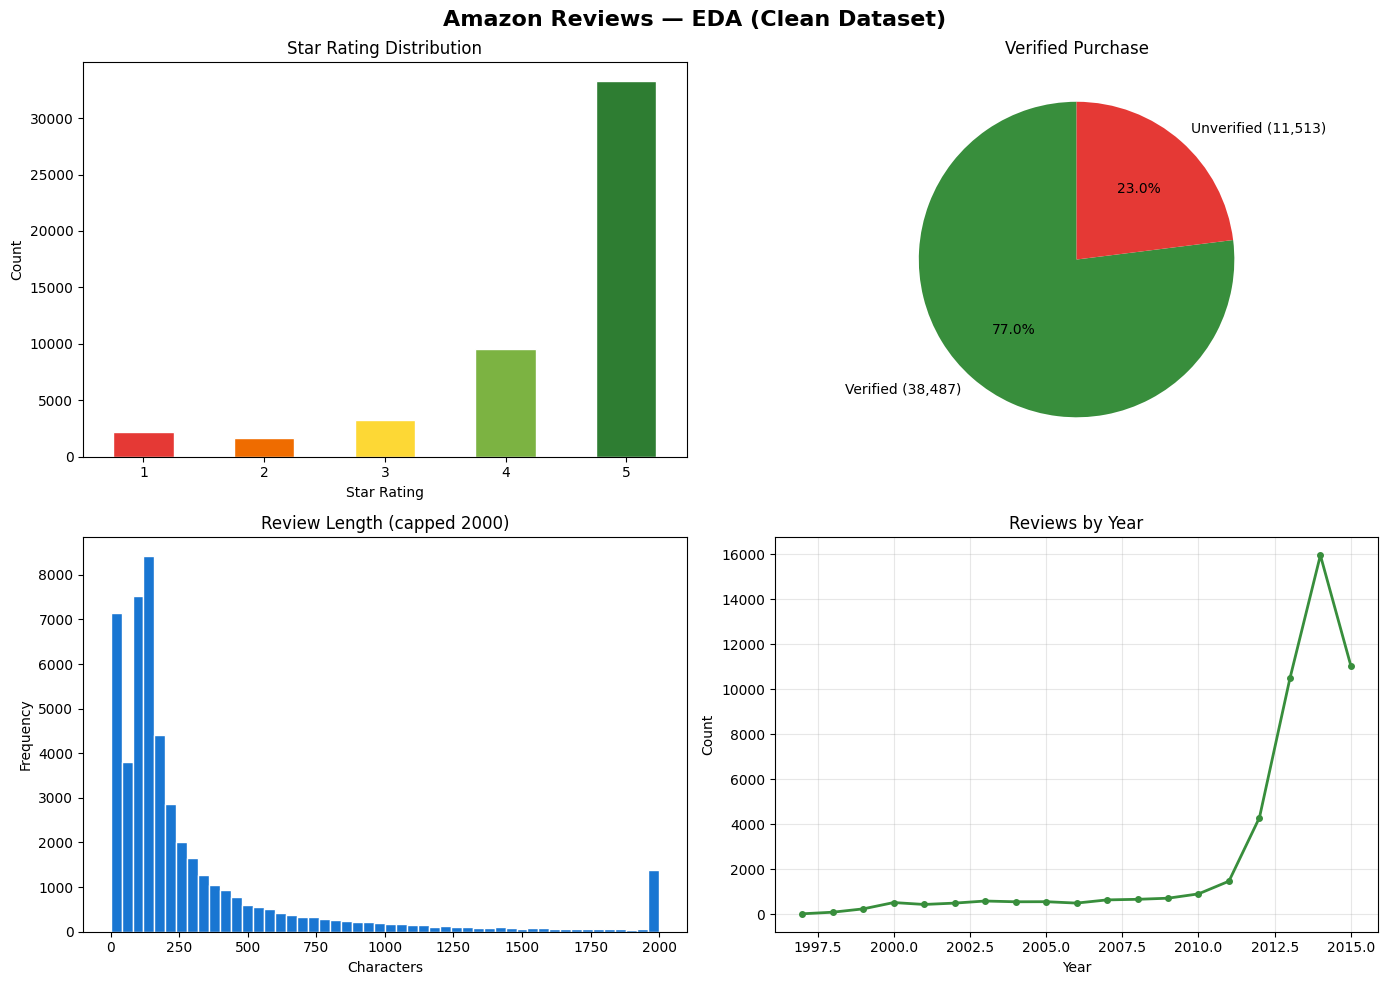

✅ EDA done | RAM: 1.42822265625%


In [9]:
#EDA
# Load sample of clean reviews for EDA plotting (50k rows)
df = pd.read_parquet(PARQUET_PATH).sample(n=min(SAMPLE_SIZE, total_clean), random_state=42)
print(f"📐 {len(df):,} rows × {df.shape[1]} columns")

rc = df['star_rating'].value_counts().sort_index()
vp = df['verified_purchase'].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Amazon Reviews — EDA (Clean Dataset)', fontsize=16, fontweight='bold')

rc.plot(kind='bar', ax=axes[0,0],
    color=['#e53935','#ef6c00','#fdd835','#7cb342','#2e7d32'], edgecolor='white')
axes[0,0].set_title('Star Rating Distribution')
axes[0,0].set_xlabel('Star Rating'); axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

axes[0,1].pie(vp.values,
    labels=[f'{"Verified" if l=="Y" else "Unverified"} ({v:,})' for l,v in zip(vp.index,vp.values)],
    colors=['#388e3c','#e53935'], autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Verified Purchase')

axes[1,0].hist(df['review_length'].clip(upper=2000), bins=50, color='#1976d2', edgecolor='white')
axes[1,0].set_title('Review Length (capped 2000)')
axes[1,0].set_xlabel('Characters'); axes[1,0].set_ylabel('Frequency')

rby = df.groupby(df['review_date'].dt.year).size()
rby.plot(kind='line', ax=axes[1,1], color='#388e3c', linewidth=2, marker='o', markersize=4)
axes[1,1].set_title('Reviews by Year')
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('Count')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{project_path}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
gc.collect()
print(f"✅ EDA done | RAM: {ram()}%")